# <span style='color:red;'> INTRODUCCION </span>

Zuber es una nueva empresa de viajes compartidos que está lanzando operaciones en Chicago. Como analista de datos,  la misión es identificar patrones de comportamiento en el mercado de transporte de la ciudad para tomar decisiones estratégicas basadas en datos.

HIPÓTESIS A PROBAR:
-----------------------------------------------------------------------------
"La duración promedio de los viajes desde el Loop hasta el 
Aeropuerto Internacional O'Hare cambia los sábados lluviosos"

Esta hipótesis es estratégicamente importante porque:

- Loop → O'Hare es una de las rutas más demandadas de Chicago
- Los viajes al aeropuerto son críticos para los usuarios
- El clima puede impactar directamente la experiencia del cliente
- Entender este patrón permite optimizar precios y tiempos estimados

# <span style='color:red;'> OBJETIVOS </span>

## Objetivo general

- Comprender las preferencias de los pasajeros y el impacto de los factores externos en los viajes.

## Objetivos específicos 

- Examinar los datos de las empresas de taxi competidoras para entender la distribución del mercado, identificar a los actores dominantes y detectar oportunidades.

- Identificar los barrios con mayor actividad de viajes para optimizar la distribución de conductores y recursos.

- Evaluar el impacto de las condiciones climáticas en el comportamiento de los viajes en la ciudad.

- Validar estadísticamente si el clima afecta la duración de los viajes en rutas específicas de alta demanda.

# <span style='color:red;'>PLAN DE ANALISIS</span>

**1. CARGA, INTEGRACIÓN Y LIMPIEZA DE DATOS**

- Importar los conjuntos de datos CSV, verificar su estructura y revisar valores nulos, duplicados y datos inconsistentes.
- Corregir tipos de datos (fechas, numéricos, strings) y estandarizar variables para garantizar consistencia.

**2. CÁLCULO Y GENERACIÓN DE VARIABLES RELEVANTES**

- Crear variables para separar datos en dos grupos:
     · Grupo 1: Sábados lluviosos (weather = 'Bad')
     · Grupo 2: Sábados con buen clima (weather = 'Good')
- Convertir duración de segundos a minutos para interpretación.
- Calcular promedios de viajes por barrio y condición climática.

**3. ANÁLISIS EXPLORATORIO DE DATOS (EDA)**

- Analizar distribución de viajes por empresa de taxi.
- Identificar el Top 10 de barrios con más finalizaciones.
- Explorar condiciones climáticas durante los viajes.
- Visualizar patrones con gráficos de barras por empresas y barrios para identificar actores y zonas dominantes.

**4. ANÁLISIS ESTADÍSTICO Y PRUEBA DE HIPÓTESIS**

- Comparar duración promedio entre ambos grupos: Sábados lluvioso y Sábados con buen clima.
- Aplicar prueba t de Welch con alfa = 0.05.

**5. INTERPRETACIÓN DE RESULTADOS Y CONCLUSIONES**

- Interpretar el valor p y estadístico t obtenidos.
- Evaluar el impacto práctico de la diferencia en minutos.
- Identificar patrones clave del mercado de taxis en Chicago.
- Formular recomendaciones estratégicas para Zuber basadas en los hallazgos del análisis.

# <span style='color:red;'>IMPORTAR DATOS </span>

In [1]:
# Importar librerías 

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns 
import math as mt
from scipy import stats as st
from matplotlib import ticker

In [8]:
# Importar archivos

companys = pd.read_csv("/Users/Loarte Juan/Documents/Dataset_project_8/moved_project_sql_result_01.csv")

locations = pd.read_csv("/Users/Loarte Juan/Documents/Dataset_project_8/moved_project_sql_result_04.csv")

hipotesis = pd.read_csv("/Users/Loarte Juan/Documents/Dataset_project_8/moved_project_sql_result_07.csv")

In [3]:
# Información de lo Dataframes 1 'companys'
#Dataframe 1

print("--" * 50)
print('Información general del DataFrame')
print(companys.info())

print("--" * 50)
print('Descripción del Dataframe')
print(companys.describe())

print('--' * 50)
print(f"Dataset: {companys.shape[0]:,} filas y {companys.shape[1]} columnas ")
print(f'Filas dupicadas: {companys.duplicated().sum()}')

print("--" * 50)
print('Valores nulos por columnas')
print(companys.isnull().sum())

print("--" * 50)
print('Tipos de datos')
print(companys.dtypes)

print('--' * 50)
print('Primeras 5 filas')
print(companys.head())

----------------------------------------------------------------------------------------------------
Información general del DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
----------------------------------------------------------------------------------------------------
Descripción del Dataframe
       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000
----------------------------------------------------------------------------------------------------
Dataset: 64 filas y 2 columnas 
Filas dupicadas: 0
---------------------------------------------------------------------------------

In [4]:
# Descripción general del Dataframe 2 'locations'
# Datafeame 2

print('--' * 50)
print('Información general del DataFrame')
print(locations.info())

print('--' * 50)
print('Descripción del Dataframe')
print(locations.describe())

print('--' * 50)
print(f"Dataset: {locations.shape[0]:,} filas y {locations.shape[1]} columnas")
print(f"Filas duplicadas: {locations.duplicated().sum()}")

print('--' * 50)
print('Valores nulos por columnas')
print(locations.isnull().sum())

print('--' * 50)
print('Tipos de datos')
print(locations.dtypes)

print('--' * 50)
print('Primeras 5 filas')
print(locations.head())

----------------------------------------------------------------------------------------------------
Información general del DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None
----------------------------------------------------------------------------------------------------
Descripción del Dataframe
       average_trips
count      94.000000
mean      599.953728
std      1714.591098
min         1.800000
25%        14.266667
50%        52.016667
75%       298.858333
max     10727.466667
----------------------------------------------------------------------------------------------------
Dataset: 94 filas y 2 columnas
Filas duplicadas: 0
------------------------------

## Observación de las tablas:

**CALIDAD DE LOS DATOS:**

Tras revisar los conjuntos de datos se confirma que la información se encuentra en óptimas condiciones para el análisis:

- Sin valores nulos ni registros duplicados detectados.
- Tipos de datos correctos en cada columna.
- Registros consistentes dentro de los rangos esperados.
- Las variables claves presentan valores coherentes y completos

Los datos no requieren limpieza adicional y están listos para continuar con el análisis exploratorio.

# <span style='color:red;'>ANALISIS DE DATOS</span>

## <span style='color:red;'>Gráfico 1. Empresas de taxis y número de viajes </span>

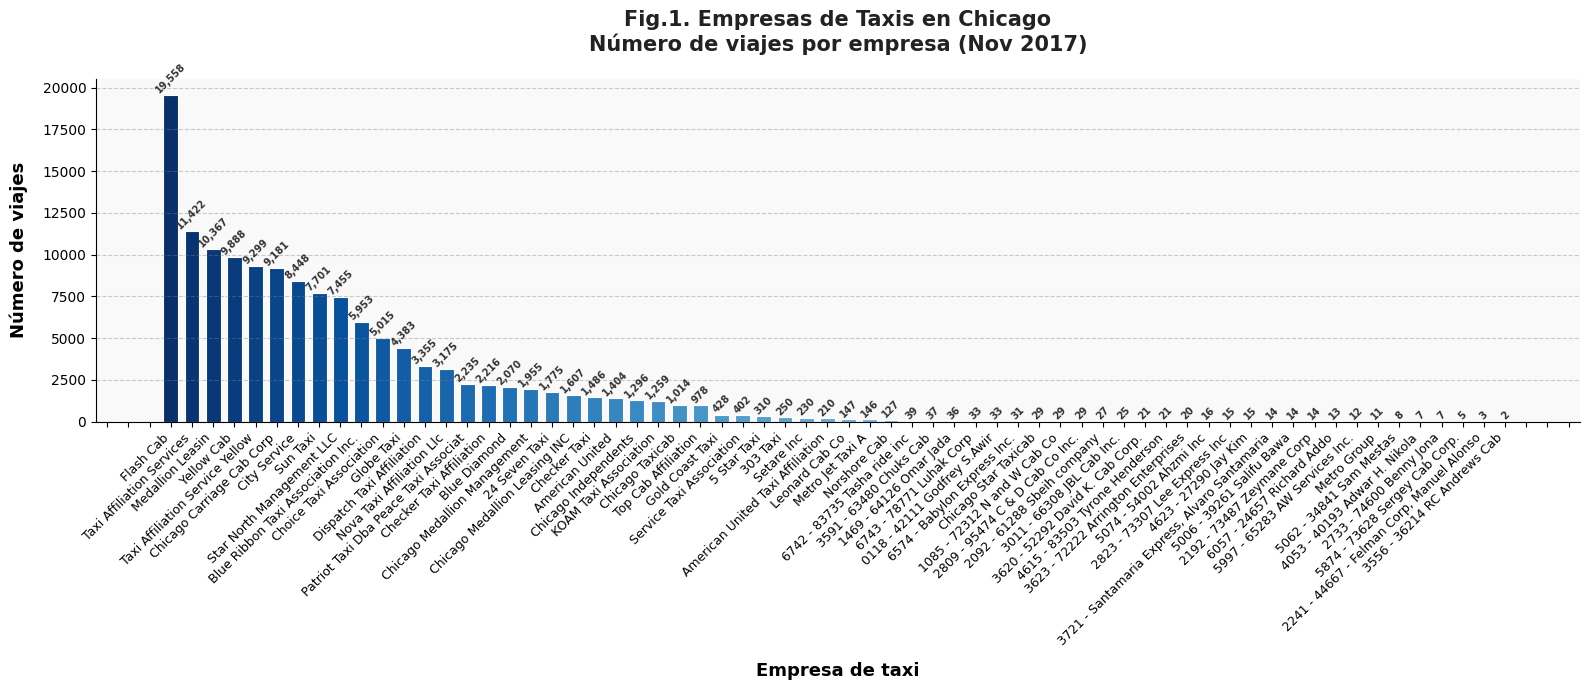

In [5]:
# 1 Gráfico de empresas de taxis y número de viajes

x_data = companys['company_name'] 
y_data = companys['trips_amount']

fig, ax = plt.subplots(figsize=(16, 7))

# Barras con degradado de color por valor
bars = ax.bar(x_data, y_data,
             color=plt.cm.Blues_r([i/len(x_data) for i in range(len(x_data))]),
             edgecolor='white',
             linewidth=0.8,
             width=0.7)

# Agregar valores encima de cada barra
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{int(height):,}',
           ha = 'center', va= 'bottom', rotation=45,
           fontsize = 7, fontweight='bold', color= '#333333')

# Títulos y etiquetas
ax.set_title('Fig.1. Empresas de Taxis en Chicago\nNúmero de viajes por empresa (Nov 2017)',
             fontsize=15, fontweight='bold', pad=20, color='#222222')
ax.set_xlabel('Empresa de taxi', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('Número de viajes', fontsize=13, fontweight='bold', labelpad=10)

# Estilo de los ejes
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=10)

# Grid y fondo
ax.grid(axis='y', linestyle='--', alpha=0.4, color='gray')
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#ffffff')

#Quitar bordes innecesarios
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Descripción del gráfico 1

Las empresas Flash Cab domina con aproximadamente 19,558 viajes, seguido de Taxi Affiliation Services con 11,422 viajes son las más representativas del mercado. A partir de la tercera empresa Medallion Leasin los valores caen drásticamente y se mantienen bajos, con decenas de empresas acumulado menos de 1,000 viajes cada una.

El mercado de taxis en Chicago pocas empresas grandes manejan la mayoría de los viajes mientras existe una larga cola de empresas pequeñas con participación mínima; esta distribución se denomina **distribución de cola larga** y es muy común en mercados de transporte.

Cualquier análisis de tendencias deben enfocarse en las dos primeras empresas de taxis (Flash Cab y Taxi Affiliation Services), para obtener conclusiones significativas del mercado.


## <span style='color:red;'>Gráfico 2. Top 10 barrios principales </span>

----------------------------------------------------------------------------------------------------
10 principales barrios por finalización de recorrido
----------------------------------------------------------------------------------------------------
   dropoff_location_name  average_trips
1                   Loop   10727.466667
2            River North    9523.666667
3          Streeterville    6664.666667
4              West Loop    5163.666667
5                 O'Hare    2546.900000
6              Lake View    2420.966667
7             Grant Park    2068.533333
8          Museum Campus    1510.000000
9             Gold Coast    1364.233333
10    Sheffield & DePaul    1259.766667


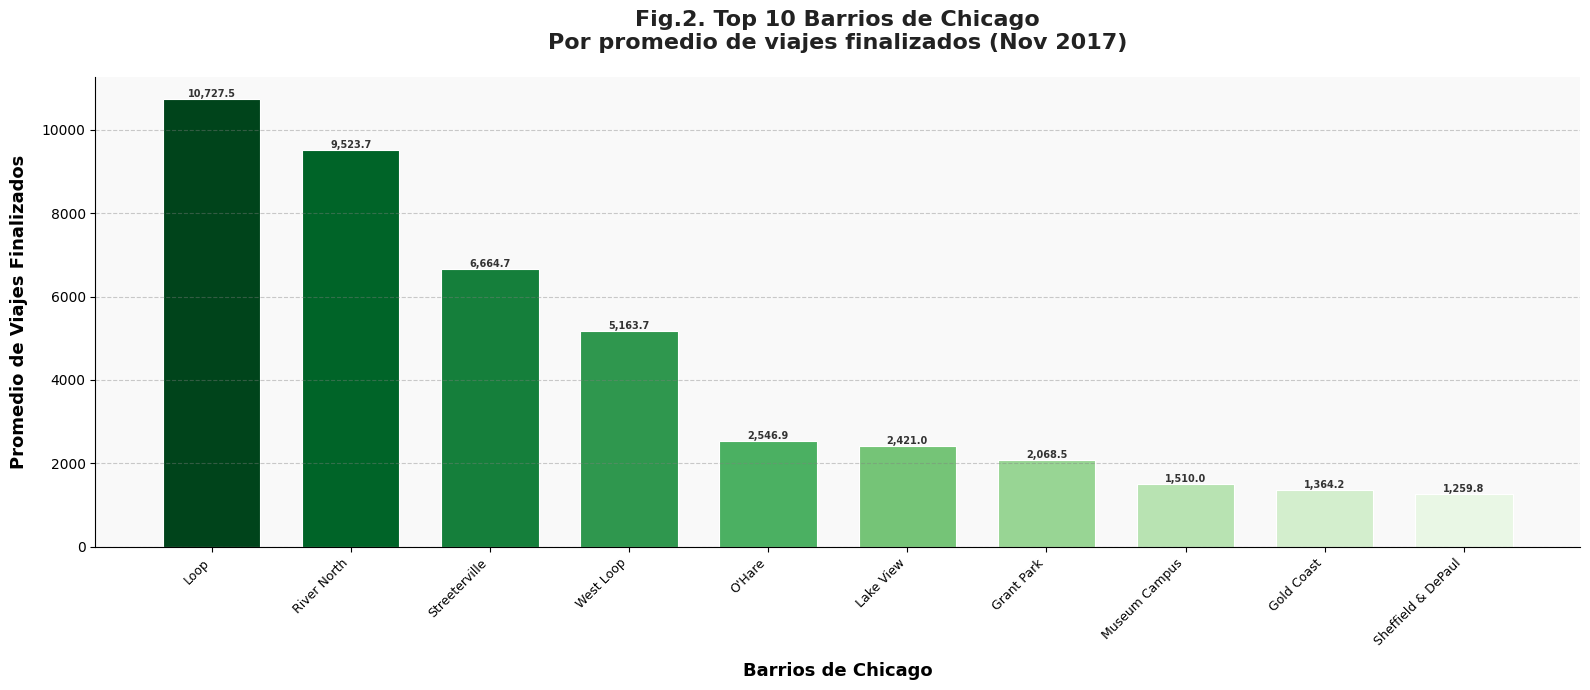

In [6]:
# Gráfico de los 10 barrios principales por número de finalizaciones
# identificar los 10 principales barrios en términos de finalización del recorrido
print('--' * 50)
print('10 principales barrios por finalización de recorrido')
print('--' * 50)

top_10_barrios = locations.sort_values(by= 'average_trips', ascending=False).head(10).reset_index(drop=True)
top_10_barrios.index += 1 
print(top_10_barrios)

# Gráfico
x_data2 = top_10_barrios['dropoff_location_name']
y_data2 = top_10_barrios['average_trips']

fig, ax1 = plt.subplots(figsize=(16, 7))

# Barras con degradado de color por valor
bars = ax1.bar(x_data2, y_data2,
             color=plt.cm.Greens_r([i/len(x_data2) for i in range(len(x_data2))]),
             edgecolor='white',
             linewidth=0.8,
             width=0.7)

# Agregar valores encima de cada barra
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:,.1f}',
           ha = 'center', va='bottom',
           fontsize=7, fontweight='bold', color='#333333')

# Títulos y etiquetas
ax1.set_title('Fig.2. Top 10 Barrios de Chicago\nPor promedio de viajes finalizados (Nov 2017)', fontsize=16,
            fontweight='bold', pad=20, color='#222222')
ax1.set_xlabel('Barrios de Chicago', fontsize=13, fontweight='bold', labelpad=10)
ax1.set_ylabel('Promedio de Viajes Finalizados', fontsize=13, fontweight='bold', labelpad=10)

# Estilo de los ejes
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=10)

# Grid y fondo
ax1.grid(axis='y', linestyle='--', alpha=0.4, color='gray')
ax1.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#ffffff')

# Quitar bordes innecesarios
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## Descripción del gráfico 2 

El Barrio Loop de Chicago lidera con 10,727.5 viajes promedio, seguido por River North con 9,523.7. A partir del tercer barrio Streeterville con 6,664.7 presenta una caída progresiva hasta Sheffield & DePaul con solo 1,259.8 viajes promedio. 

Los destinos Loop y River North son los más populares y favoritos del público en general, ya que son barrios que concentran el centro financiero y entretenimiento de Chicago. Se observa una pronunciada diferencia entre el primer barrio (10,727.5) y el décimo (1,259.8) aproximadamente de 8.5 veces, lo que indica una concentración muy fuerte en los barrios del centro de la ciudad.   

Los Barrios Loop y O Hare son los barrios clave para nuestra hipótesis, ambos están entre los 10 más activos, lo que garantiza suficientes datos para analizar el impacto del clima
en los viajes entre estos dos puntos.



# <span style='color:red;'>PRUEBA DE HIPOTESIS </span>

In [16]:
# Descripción general del Dataframe 3: Weather Conditions

print('--' * 25)
print('Primeras 5 filas')
print(hipotesis.head())

print('--' * 25)
print('Información general del DataFrame')
print(hipotesis.info())

print('--' * 25)
print('Tipo de datos')
print(hipotesis.dtypes)

print('--' * 25)
print('Valores nulos por columna')
print(hipotesis.isnull().sum())


print('--' * 25)
print(f"Dataset: {hipotesis.shape[0]} filas y {hipotesis.shape[1]} columnas")
print(f"Filas duplicadas: {hipotesis.duplicated().sum()}")
print('--' * 25)
# Verifica qué filas están duplicados
duplicates = hipotesis[hipotesis.duplicated()]
print('Filas duplicadas:')
print(duplicates.head())

--------------------------------------------------
Primeras 5 filas
              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0
--------------------------------------------------
Información general del DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None
--------------------------------------------------
Tipo de datos
start_ts     

## Observación de las tabla:

**ESTRUCTURA DE LA TABLA 'HIPOTESIS'**

- Filas:    1,068 registros
- Columnas: 3 (start_ts, weather_conditions, duration_seconds)

**CALIDAD DE DATOS:**

- Valores nulos: 0 no requiere tratamiento
- Valores duplicados: 197, estas filas se conservan porque representan viajes reales que coinciden en hora de inicio, condición climática y duración, lo cual es válido en un sistema
de transporte de alta demanda.

**TRANSFORMACIÓN NECESARIA:**

- Columna 'start_ts': tipo object  a datetime64; esta conversión es indispensable para poder extraer correctamente el día de la semana y filtrar los sábados en la prueba de hipótesis.

**AGRUPAR DIAS**

- En la tabla se observa dos condiciones climáticas: 'Good' and 'Bad', de igual manera se observa que la columna 'start_ts' contiene solo información de días sábados; por lo tanto se agrupan en dos grupos representativos:  sábados lluviosos & sábados buen clima.

## <span style='color:red;'>Preparar datos del DataFrame 'hipotesis'</span>

In [39]:
# Preparar datos del DataFrame 'hipótesis'
print("--" * 25)

# Convertir datos de la columna start_ts a datetime64
hipotesis['start_ts'] = pd.to_datetime(hipotesis['start_ts'])
print('Tipo de datos actualizados')
print(hipotesis.dtypes)
print('--' * 25)

# Crear columna del día de la semana
hipotesis['day_of_week'] = hipotesis['start_ts'].dt.dayofweek

# Verificar que sábado = 5 con una fecha conocida
fecha_sabado = pd.to_datetime('2023-12-02')  
print(f"Verificación día de la semana para {fecha_sabado.strftime('%A')} = día {fecha_sabado.dayofweek}")
print('--' * 25)

# Filtrar solo los sábados
sabados = hipotesis[hipotesis['day_of_week'] == 5]
print(f"Total de registros en sábados: {len(sabados)}")
print(f"Condiciones climáticas en sábados:")
print(sabados['weather_conditions'].value_counts())

--------------------------------------------------
Tipo de datos actualizados
start_ts              datetime64[ns]
weather_conditions            object
duration_seconds             float64
day_of_week                    int32
dtype: object
--------------------------------------------------
Verificación día de la semana para Saturday = día 5
--------------------------------------------------
Total de registros en sábados: 1068
Condiciones climáticas en sábados:
weather_conditions
Good    888
Bad     180
Name: count, dtype: int64


In [47]:
# Crear grupos: "sábados lluviosos" vs "sábados con buen clima"
print("--" * 25)

# Grupo 1: Sábados lluviosos (bad)
rainy_saturdays = hipotesis[
    (hipotesis['day_of_week'] == 5) &
    (hipotesis['weather_conditions'] == 'Bad')
]['duration_seconds']

# Grupo 2: sábados con buen clima
good_saturdays = hipotesis[~((hipotesis['day_of_week'] == 5) & 
                  (hipotesis['weather_conditions'] == 'Bad')
)]['duration_seconds']


# Duración promedio por grupo
mean_rainy_saturdays = rainy_saturdays.mean()
mean_good_saturdays = good_saturdays.mean()
diferencia_mean = mean_rainy_saturdays - mean_good_saturdays

# Convertir segundos a minutos
rainy_saturdays_minuts = mean_rainy_saturdays / 60
good_saturdays_minuts =  mean_good_saturdays / 60
diferencia_mean_minuts = diferencia_mean / 60

print(f'Viajes sábados lluviosos:     {len(rainy_saturdays)}')
print(f'Viajes sábados buen clima:    {len(good_saturdays)}')
print('--' * 25)
print(f"Promedio sábados lluviosos:   {mean_rainy_saturdays:.2f} segundos (~{rainy_saturdays_minuts:.2f} minutos)")
print(f"Promedio sábados buen clima:  {mean_good_saturdays:.2f} segundos (~{good_saturdays_minuts:.2f} minutos)")
print(f"Diferencia de promedios:      {diferencia_mean:.2f} segundos (~{diferencia_mean_minuts:.2f} minutos)")

--------------------------------------------------
Viajes sábados lluviosos:     180
Viajes sábados buen clima:    888
--------------------------------------------------
Promedio sábados lluviosos:   2427.21 segundos (~40.45 minutos)
Promedio sábados buen clima:  1999.68 segundos (~33.33 minutos)
Diferencia de promedios:      427.53 segundos (~7.13 minutos)


## <span style='color:red;'>Prueba la hipótesis: "La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos". </span>



In [54]:
# Prueba de Hipótesis
print("--" * 25)
alpha = 0.05

print('''
HIPOTESIS:
HO (Nula):          La duración promedio de los viajes Loop - O'Hare 
                    los sábados lluviosos
                    ES IGUAL a la duración de los sábados con buen clima

H1 (Alternativa):   La duración promedio de los viajes Loop - O'Hare
                    los sábados lluviosos
                    ES DIFERENTE a la duración de los sábados con buen clima

Nivel de significación: alfa = 0.05
''')

print("--" * 25)
# Prueba t de Welch para dos muestras independientes
results = st.ttest_ind(rainy_saturdays, good_saturdays, equal_var=False)

print(f"Estadístico t: {results.statistic:.4f}")
print(f"Valor p:       {results.pvalue:.4f}")
print("--" * 25)

if results.pvalue < alpha:
    print("Rechazamos HO")
    print("La duración SI cambia significativamente los sábados lluviosos")
else:
    print("NO rechazamos HO")
    print("No hay evidencia suficiente de que la duración cambie")

print("--" * 25)

--------------------------------------------------

HIPOTESIS:
HO (Nula):          La duración promedio de los viajes Loop - O'Hare 
                    los sábados lluviosos
                    ES IGUAL a la duración de los sábados con buen clima

H1 (Alternativa):   La duración promedio de los viajes Loop - O'Hare
                    los sábados lluviosos
                    ES DIFERENTE a la duración de los sábados con buen clima

Nivel de significación: alfa = 0.05

--------------------------------------------------
Estadístico t: 7.1860
Valor p:       0.0000
--------------------------------------------------
Rechazamos HO
La duración SI cambia significativamente los sábados lluviosos
--------------------------------------------------


## <span style="color:red;">Descripción de la hipótesis</span>


**Descripción de la hipótesis**

**Resultado estadístico:**

   1. Rechazamos H₀ (p < 0.0001, α = 0.05)
   2. Los viajes Loop-O'Hare duran significativamente más los sábados lluviosos

**Magnitud del efecto:**

   1. Diferencia promedio: 7.13 minutos (427.53 segundos)
   2.  Sábados lluviosos: ~40.45 minutos
   3. Sábados buen clima: ~33.33 minutos

-  Existe evidencia estadística suficiente para afirmar  que la duración promedio de los viajes desde el Loop  hasta el Aeropuerto O'Hare SÍ cambia los sábados lluviosos, por lo tanto RECHAZAMOS HO.

- Los viajes duran aproximadamente ~7.13 minutos  más cuando llueve, lo que representa un impacto real y significativo en el tiempo de traslado al aeropuerto.


# <span style= 'color:red;'>CONCLUSION </span>

Limitaciones del estudio:
-----------------------------------------------------------------------

- Datos limitados a noviembre 2017.
- Solo analiza días sábados.
- Específico para la ruta Loop-O'Hare.

La diferencia de 7.13 minutos (~427.53 segundos) entre sábados 
lluviosos y sábados con buen clima tiene 
implicaciones reales para los usuarios y en el negocio:

IMPACTO EN EL USUARIO:
-----------------------------------------------------------------------
- Un pasajero que normalmente tarda ~33 minutos en llegar
  al aeropuerto, los sábados lluviosos tardará ~40 minutos.
  
- Para alguien con un vuelo programado, 7 minutos pueden
  significar la diferencia entre abordar o perder su vuelo.

- Los usuarios deberían salir al menos 10-15 minutos antes
  de lo habitual los sábados lluviosos para llegar a tiempo.


IMPACTO EN EL NEGOCIO:
-----------------------------------------------------------------------
- Las empresas de taxi pueden anticipar mayor demanda
  y tiempos más largos los sábados lluviosos.
  
- Los conductores deben planificar más viajes cortos
  ya que cada viaje al aeropuerto tomará más tiempo.
  
- Las aplicaciones de taxi podrían ajustar sus estimaciones
  de tiempo automáticamente cuando detecten lluvia.

Por lo tanto;

El valor p extremadamente bajo (0.0000) indica que esta diferencia
No es producto de azar, sino de una tendencia real y consistente de 
datos.

POSIBLES RAZONES DEL AUMENTO DE DURACIÓN:
-----------------------------------------------------------------------
- Mayor tráfico vehicular bajo las condiciones de lluvia.
- Velocidad reducida por condiciones del pavimento mojado.
- Mayor demanda de taxis en días lluviosos.
- Visibilidad reducida que obliga a conducir con precaución, 
  para mayor seguridad.

CRITERIO Y NIVEL DE SIGNIFICACIÓN:
-----------------------------------------------------------------------
Prueba utilizada: Prueba t de Welch (two-sample, equal_var=False)
Nivel de significación: alfa = 0.05

La prueba fue seleccionada por las siguientes razones: 
- Se comparó DOS grupos independientes:
  sábados lluviosos vs sábados con buen clima.
- Se compara los PROMEDIOS de duración de los viajes.
- equal_var=False porque los grupos tienen tamaños
  diferentes (180 vs 888 viajes).
